In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from scipy.stats import pearsonr

import sys
sys.path.append("../code")
import households as hh

In [2]:
# matplotlib settings
mpl.rcParams["axes.spines.right"] = False
mpl.rcParams["axes.spines.top"] = False
mpl.rcParams["axes.titlesize"]= 8
mpl.rcParams["xtick.labelsize"] = 8
mpl.rcParams["ytick.labelsize"] = 8
mpl.rcParams["axes.labelsize"] = 10
mpl.rcParams["legend.fontsize"] = 7
mpl.rcParams["legend.title_fontsize"] = 7
mpl.rcParams["font.family"] = "Helvetica"
cm = 1/2.54

In [3]:
# load pre-processed data
data = pd.read_csv('../results/processed/(gamma=0.85,ah=0.2,europe_as_country)_data.csv', index_col=0)
data_c = pd.read_csv('../results/processed/(gamma=0.85,ah=0.2,europe_as_country)_data_c.csv', index_col=0)
data_a = pd.read_csv('../results/processed/(gamma=0.85,ah=0.2,europe_as_country)_data_a.csv', index_col=0)

mus = hh.calc_mus(0.2)

In [4]:
# definition of color groups for countries
nordic = ['SE','DK','FI','NO']
northwest = ['AT','BE','FR','DE','LU','UK','CH','NL']
south = ['GR','IT','PT','ES']
island = ['CY','MT','IS','IE']
udssr = ['AL','BG','CZ','HR','EE','PL','RO','RS','SK','SI','ME','LV','LT','HU','MK']
jugo = ['AL','SI','HR','ME','RS','MK']

def color(iso2):
    if iso2 in nordic: return 'blue'
    if iso2 in northwest: return 'green'
    if iso2 in south: return 'green'
    if iso2 in island: return 'orange'
#    if iso2 in jugo: return 'black'
    if iso2 in udssr: return 'red'
    return 'gray'

In [5]:
# collecting the information needed for plotting in one dataframe
df = pd.DataFrame(columns=['iso2','mratio','prev_real','prev_theo','color','Rout'], index=data.columns)
df.loc[:,'iso2'] = df.index.map(hh.get_iso2)
df.loc[:,'mratio'] = df['iso2'].map(hh.get_distribution).map(hh.momentratio)
df.loc[:,'prev_real'] = data.median(axis=0)
df.loc[:,'prev_theo'] = data_a.median(axis=0)
df.loc[:,'color'] = df['iso2'].map(color)
df.loc[:,'R_out'] = data_c.median(axis=0)
df.sort_values('mratio', inplace=True)

In [6]:
# calculate pearson correlation and explained variance
# (takes some time to compute, use next cell instead on replots)

#r2 = np.zeros(len(data.index))
#for i in range(len(data.index)):
#    r2[i] = hh.calc_explained_variance(data.iloc[i], data_a.iloc[i])

#pcc = np.zeros(len(data.index))
#for i in range(len(data.index)):
#    pcc[i] = hh.calc_pearson(data.iloc[i])

#np.savetxt('../results/processed/(gamma=0.85,ah=0.2,europe_as_country)_r2.csv', r2)
#np.savetxt('../results/processed/(gamma=0.85,ah=0.2,europe_as_country)_pcc.csv', pcc)

In [7]:
r2 = np.loadtxt('../results/processed/(gamma=0.85,ah=0.2,europe_as_country)_r2.csv')
pcc = np.loadtxt('../results/processed/(gamma=0.85,ah=0.2,europe_as_country)_pcc.csv')

In [8]:
weights = hh.get_polulation_array(data_c.columns)
weights /= weights.sum()
eu_prev = (data*weights).sum(axis=1).median()
eu_mratio = hh.momentratio( hh.get_european_distribution(data_c.columns) )

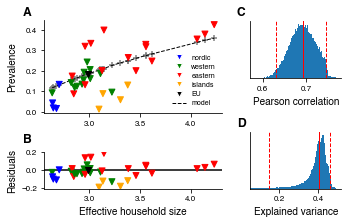

In [9]:
# plotting
fig = plt.figure(figsize=(12*cm, 3), constrained_layout=True)
subfigs = fig.subfigures(1, 2, width_ratios=[2,1], wspace=0.05)
grid_left = subfigs[0].add_gridspec(ncols=1, nrows=2, height_ratios=[5,2], hspace=0.0)
grid_right = subfigs[1].add_gridspec(ncols=1, nrows=2, hspace=0.1)
ax1 = subfigs[0].add_subplot(grid_left[0])
ax2 = subfigs[0].add_subplot(grid_left[1], sharex=ax1)
ax3 = subfigs[1].add_subplot(grid_right[0])
ax4 = subfigs[1].add_subplot(grid_right[1])

ax1.scatter(df['mratio'], df['prev_real'], color=df['color'], marker='v')
ax1.scatter(eu_mratio, eu_prev, color='black', marker='v')
ax1.scatter(df['mratio'], df['prev_theo'], color='gray', marker='+', zorder=0)
#ax1.plot(df['mratio'], df['prev_theo_b'], color='red', lw=1, ls='--', zorder=0)
#ax1.plot(df['mratio'], df['prev_theo_w'], color='blue', lw=1, ls='--', zorder=0)
ax1.plot(df['mratio'], df['prev_theo'], color='black', lw=1, ls='--', zorder=0)
#ax1.set_xlabel(r'Effective household size')
ax1.set_ylabel(r'Prevalence')

ax2.scatter(df['mratio'], df['prev_real']-df['prev_theo'], color=df['color'], marker='v')
ax2.scatter(eu_mratio, 0, color='black', marker='v')
ax2.axhline(0, color='black', zorder=0)
ax2.set_xlabel(r'Effective household size')
ax2.set_ylabel(r'Residuals')

ax3.hist(pcc, bins=100, density=True)
ax3.axvline(np.percentile(pcc,2.5), color='red', lw=1, ls='--')
ax3.axvline(np.percentile(pcc,97.5), color='red', lw=1, ls='--')
ax3.axvline(np.percentile(pcc,50), color='red', lw=1)
ax3.set_xlabel(r'Pearson correlation')
#ax3.set_ylabel(r'Frequency')
ax3.set_yticks([])

ax4.hist(r2[r2>0], bins=100, density=True)
ax4.set_xlim(0.05, 0.52)
ax4.axvline(np.percentile(r2,2.5), color='red', lw=1, ls='--')
ax4.axvline(np.percentile(r2,97.5), color='red', lw=1, ls='--')
ax4.axvline(np.percentile(r2,50), color='red', lw=1)
ax4.set_xlabel('Explained variance')
ax4.set_yticks([])

ax1.text(-.12,1.05, 'A', size=12, weight='bold', color='black', transform=ax1.transAxes)
ax2.text(-.12,1.25, 'B', size=12, weight='bold', color='black', transform=ax2.transAxes)
ax3.text(-.15,1.1, 'C', size=12, weight='bold', color='black', transform=ax3.transAxes)
ax4.text(-.15,1.1, 'D', size=12, weight='bold', color='black', transform=ax4.transAxes)


legend_elements = [mpl.lines.Line2D([0], [0], marker='v', color='w',
                    markerfacecolor=color(nordic[0]), label='nordic'),
                   mpl.lines.Line2D([0], [0], marker='v', color='w',
                    markerfacecolor=color(northwest[0]), label='western'),
                   mpl.lines.Line2D([0], [0], marker='v', color='w',
                    markerfacecolor=color(udssr[0]), label='eastern'),
                   mpl.lines.Line2D([0], [0], marker='v', color='w',
                    markerfacecolor=color(island[0]), label='islands'),
                   mpl.lines.Line2D([0], [0], marker='v', color='w',
                    markerfacecolor='black', label='EU'),
                   mpl.lines.Line2D([0], [0], color='black', lw=1, ls='--', label='model')]
ax1.legend(handles=legend_elements, frameon=False, labelspacing=0.3)

subfigs[0].align_ylabels()
fig.savefig('../figures/figure_2.pdf')

In [10]:
print('Pearson correlation 2.5,50,97.5:', np.percentile(pcc,2.5), np.percentile(pcc,50), np.percentile(pcc,97.5))
print('Explained variance 2.5,50,97.5:', np.percentile(r2,2.5), np.percentile(r2,50), np.percentile(r2,97.5))

Pearson correlation 2.5,50,97.5: 0.6314061153574942 0.6918754945392729 0.7454799370009924
Explained variance 2.5,50,97.5: 0.14703074611359904 0.4059244973789488 0.46108263098068086


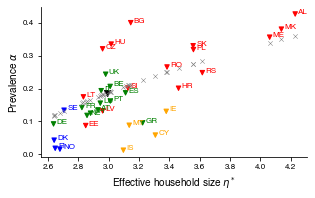

In [11]:
fig,ax = plt.subplots(figsize=(12.1*cm,7*cm))

ax.scatter(df['mratio'], df['prev_real'], color=df['color'], marker='v', s=20)
ax.scatter(eu_mratio, eu_prev, color='black', marker='v')
ax.scatter(df['mratio'], df['prev_theo'], color='gray', marker='x',s=20, lw=0.5)
#ax.plot(df['mratio'], df['prev_theo'], color='black', lw=1, ls='--', zorder=0)

for x,y,lab,col in zip(df['mratio'],df['prev_real'],df['iso2'],df['color']):
    ax.text(x+0.02,y,lab,size=8,color=col)
    
ax.set_xlabel(r'Effective household size $\eta^*$',size=10)
ax.set_ylabel(r'Prevalence $\alpha$',size=10)

plt.savefig('../figures/figure_S7.pdf')

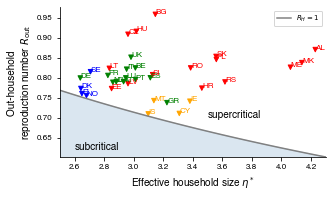

In [12]:
fig,ax = plt.subplots(figsize=(12.1*cm,7*cm))


mratio = np.linspace(2.5,4.3,100)
a_h = 0.2


def c_crit(a_h,mratio):
    return 1/(1+a_h*(mratio-1))

def R_H(c,a_h,mratio):
    return c*(1+a_h*(mratio-1))

ax.plot(mratio,c_crit(a_h,mratio),color='grey',lw=1.5,label='$R_H=1$')
ax.set_xlim(mratio[0],mratio[-1])

ax.scatter(df['mratio'], df['R_out'], color=df['color'], marker='v', s=20)

for x,y,lab,col in zip(df['mratio'],df['R_out'],df['iso2'],df['color']):
    ax.text(x+0.002,y,lab,size=8,color=col)
    
ax.set_xlabel(r'Effective household size $\eta^*$',size=10)
label_rout = r'$R_{\rm out}$'
ax.set_ylabel(f'Out-household \nreproduction number {label_rout}',size=10)

ax.set_ylim(c_crit(a_h,mratio)[-1],None)

ax.fill_between(mratio,c_crit(a_h,mratio),color='steelblue',alpha=0.2)

ax.text(3.5,0.7,'supercritical',size=10)
ax.text(2.6,0.62,'subcritical',size=10)

ax.legend()

plt.savefig('../figures/figure_S8.pdf')